In [1]:
# Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Создаем папку для артефактов
import os
ARTIFACTS_PATH = '/content/drive/MyDrive/seminars/S13'
os.makedirs(ARTIFACTS_PATH, exist_ok=True)
print(f"Артефакты будут сохранены в: {ARTIFACTS_PATH}")

Mounted at /content/drive
Артефакты будут сохранены в: /content/drive/MyDrive/seminars/S13


In [2]:
# Импортируем библиотеки
import torch
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from transformers import EarlyStoppingCallback

import warnings
warnings.filterwarnings('ignore')

# Фиксируем seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


**Загрузка и анализ датасета**

In [19]:
# Загружаем датасет emotion (рекомендуемый по умолчанию)
dataset = load_dataset("emotion")

# Анализируем датасет
print("=" * 50)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 50)
print(f"Размер train: {len(dataset['train'])}")
print(f"Размер validation: {len(dataset['validation'])}")
print(f"Размер test: {len(dataset['test'])}")

# Получаем названия классов
label_names = dataset['train'].features['label'].names
print(f"\nКлассы ({len(label_names)} классов):")
for i, name in enumerate(label_names):
    print(f"  {i}: {name}")

# Показываем примеры
print("\n" + "=" * 50)
print("ПРИМЕРЫ ТЕКСТОВ И МЕТОК")
print("=" * 50)
for i in range(5):
    text = dataset['train'][i]['text']
    label = dataset['train'][i]['label']
    label_name = label_names[label]
    print(f"\nПример {i+1}:")
    print(f"Текст: {text}")
    print(f"Метка: {label} ({label_name})")

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер train: 16000
Размер validation: 2000
Размер test: 2000

Классы (6 классов):
  0: sadness
  1: joy
  2: love
  3: anger
  4: fear
  5: surprise

ПРИМЕРЫ ТЕКСТОВ И МЕТОК

Пример 1:
Текст: i didnt feel humiliated
Метка: 0 (sadness)

Пример 2:
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Метка: 0 (sadness)

Пример 3:
Текст: im grabbing a minute to post i feel greedy wrong
Метка: 3 (anger)

Пример 4:
Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Метка: 2 (love)

Пример 5:
Текст: i am feeling grouchy
Метка: 3 (anger)


**Демонстрация токенизации**

In [20]:
# Загружаем токенизатор BERT
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("=" * 50)
print("ТОКЕНИЗАЦИЯ ТЕКСТА")
print("=" * 50)

# Берем несколько примеров из датасета
sample_texts = [
    dataset['train'][0]['text'],
    dataset['train'][1]['text'],
    dataset['train'][2]['text'],
    "I am feeling very happy today!",
    "This is a longer sentence to demonstrate padding and truncation in action."
]

for i, text in enumerate(sample_texts):
    print(f"\n--- Пример {i+1} ---")
    print(f"Оригинальный текст: {text}")

    # Токенизируем
    tokens = tokenizer.tokenize(text)
    print(f"Токены: {tokens}")

    # Получаем input_ids
    encoded = tokenizer(text, return_tensors="pt")
    print(f"input_ids: {encoded['input_ids'][0].tolist()}")
    print(f"attention_mask: {encoded['attention_mask'][0].tolist()}")

    # Показываем special tokens
    print(f"Special tokens: [CLS]={tokenizer.cls_token_id}, [SEP]={tokenizer.sep_token_id}, [PAD]={tokenizer.pad_token_id}")

# Демонстрация padding и truncation
print("\n" + "=" * 50)
print("PADDING И TRUNCATION")
print("=" * 50)

texts = ["Short text", "This is a much longer text that might need truncation"]
encoded_padded = tokenizer(texts, padding=True, return_tensors="pt")
print("С разным padding (max_length=10):")
encoded_truncated = tokenizer(texts, padding=True, truncation=True, max_length=10, return_tensors="pt")
print(f"input_ids после padding и truncation:\n{encoded_truncated['input_ids']}")
print(f"attention_mask после padding и truncation:\n{encoded_truncated['attention_mask']}")

ТОКЕНИЗАЦИЯ ТЕКСТА

--- Пример 1 ---
Оригинальный текст: i didnt feel humiliated
Токены: ['i', 'didn', '##t', 'feel', 'humiliated']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS]=101, [SEP]=102, [PAD]=0

--- Пример 2 ---
Оригинальный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS]=101, [SEP]=102, [PAD]=0

--- Пример 3 ---
Оригинальный текст: im grabbing a minute to post i feel greedy wrong
Токены: ['im', 'grabbing', 'a', '

**Инференс готовой модели**

In [21]:
print("=" * 50)
print("ИНФЕРЕНС ГОТОВОЙ МОДЕЛИ")
print("=" * 50)

# Используем pipeline для анализа тональности
sentiment_pipeline = pipeline("sentiment-analysis", device=0 if torch.cuda.is_available() else -1)

# Тестовые тексты разного характера
test_texts = [
    "I love this movie, it's absolutely fantastic!",
    "This product is terrible, I hate it.",
    "The weather today is okay, nothing special.",
    "I am so excited about my vacation!",
    "The service was disappointing and slow."
]

print("\nРезультаты анализа тональности (готовой моделью):")
for text in test_texts:
    result = sentiment_pipeline(text)[0]
    print(f"\nТекст: {text}")
    print(f"Предсказание: {result['label']} (confidence: {result['score']:.3f})")

print("\n" + "=" * 50)
print("АНАЛИЗ ПРИГОДНОСТИ МОДЕЛИ")
print("=" * 50)
print("Готовая модель sentiment-analysis предсказывает только позитив/негатив.")
print(f"Наш датасет '{dataset['train'].features['label'].names}' имеет {len(label_names)} эмоциональных классов.")
print("Готовая модель НЕ подходит для нашей задачи, так как она не различает разные эмоции,")
print("а только определяет общую тональность (положительную/отрицательную).")
print("Поэтому необходим fine-tuning для классификации по 6 эмоциям.")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


ИНФЕРЕНС ГОТОВОЙ МОДЕЛИ


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Результаты анализа тональности (готовой моделью):

Текст: I love this movie, it's absolutely fantastic!
Предсказание: POSITIVE (confidence: 1.000)

Текст: This product is terrible, I hate it.
Предсказание: NEGATIVE (confidence: 1.000)

Текст: The weather today is okay, nothing special.
Предсказание: NEGATIVE (confidence: 0.995)

Текст: I am so excited about my vacation!
Предсказание: POSITIVE (confidence: 1.000)

Текст: The service was disappointing and slow.
Предсказание: NEGATIVE (confidence: 1.000)

АНАЛИЗ ПРИГОДНОСТИ МОДЕЛИ
Готовая модель sentiment-analysis предсказывает только позитив/негатив.
Наш датасет '['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']' имеет 6 эмоциональных классов.
Готовая модель НЕ подходит для нашей задачи, так как она не различает разные эмоции,
а только определяет общую тональность (положительную/отрицательную).
Поэтому необходим fine-tuning для классификации по 6 эмоциям.


**Подготовка данных для fine-tuning**

In [22]:
print("=" * 50)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ FINE-TUNING")
print("=" * 50)

# Токенизируем весь датасет
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

print("Токенизация train split...")
tokenized_train = dataset["train"].map(tokenize_function, batched=True)
print("Токенизация validation split...")
tokenized_val = dataset["validation"].map(tokenize_function, batched=True)
print("Токенизация test split...")
tokenized_test = dataset["test"].map(tokenize_function, batched=True)

# Преобразуем в формат PyTorch
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_val.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(f"\nГотово! Размер train: {len(tokenized_train)}")
print(f"Размер validation: {len(tokenized_val)}")
print(f"Размер test: {len(tokenized_test)}")

ПОДГОТОВКА ДАННЫХ ДЛЯ FINE-TUNING
Токенизация train split...
Токенизация validation split...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Токенизация test split...

Готово! Размер train: 16000
Размер validation: 2000
Размер test: 2000


**Fine-tuning модели**

In [13]:
print("=" * 50)
print("FINE-TUNING МОДЕЛИ")
print("=" * 50)

# Загружаем модель для классификации
num_labels = len(label_names)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)
model.to(device)

# Настройки обучения (исправленная версия)
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    report_to="none",
    save_total_limit=2,
    disable_tqdm=True,
)

# Функция для вычисления метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": accuracy, "f1_macro": f1}

# Создаем Trainer (исправленная версия - убираем tokenizer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Обучаем модель
print("\nНачинаем обучение...")
trainer.train()

print("\n" + "=" * 50)
print("ОЦЕНКА НА VALIDATION")
print("=" * 50)
val_results = trainer.evaluate()
print(f"Validation Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"Validation F1 Macro: {val_results['eval_f1_macro']:.4f}")

FINE-TUNING МОДЕЛИ


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Начинаем обучение...
{'loss': '1.676', 'grad_norm': '7.134', 'learning_rate': '1.967e-05', 'epoch': '0.05'}
{'loss': '1.394', 'grad_norm': '5.921', 'learning_rate': '1.934e-05', 'epoch': '0.1'}
{'loss': '1.199', 'grad_norm': '10.63', 'learning_rate': '1.901e-05', 'epoch': '0.15'}
{'loss': '0.9401', 'grad_norm': '14.68', 'learning_rate': '1.867e-05', 'epoch': '0.2'}
{'loss': '0.75', 'grad_norm': '31.08', 'learning_rate': '1.834e-05', 'epoch': '0.25'}
{'loss': '0.5531', 'grad_norm': '5.476', 'learning_rate': '1.801e-05', 'epoch': '0.3'}
{'loss': '0.4773', 'grad_norm': '5.992', 'learning_rate': '1.767e-05', 'epoch': '0.35'}
{'loss': '0.3826', 'grad_norm': '14.77', 'learning_rate': '1.734e-05', 'epoch': '0.4'}
{'loss': '0.319', 'grad_norm': '8.481', 'learning_rate': '1.701e-05', 'epoch': '0.45'}
{'loss': '0.3172', 'grad_norm': '18.27', 'learning_rate': '1.667e-05', 'epoch': '0.5'}
{'loss': '0.2873', 'grad_norm': '0.7545', 'learning_rate': '1.634e-05', 'epoch': '0.55'}
{'loss': '0.2741', '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1092', 'grad_norm': '0.4181', 'learning_rate': '6.34e-06', 'epoch': '2.05'}
{'loss': '0.09412', 'grad_norm': '1.458', 'learning_rate': '6.007e-06', 'epoch': '2.1'}
{'loss': '0.1229', 'grad_norm': '0.9747', 'learning_rate': '5.673e-06', 'epoch': '2.15'}
{'loss': '0.09093', 'grad_norm': '26.82', 'learning_rate': '5.34e-06', 'epoch': '2.2'}
{'loss': '0.07964', 'grad_norm': '7.529', 'learning_rate': '5.007e-06', 'epoch': '2.25'}
{'loss': '0.09658', 'grad_norm': '5.462', 'learning_rate': '4.673e-06', 'epoch': '2.3'}
{'loss': '0.1026', 'grad_norm': '2.623', 'learning_rate': '4.34e-06', 'epoch': '2.35'}
{'loss': '0.1091', 'grad_norm': '2.304', 'learning_rate': '4.007e-06', 'epoch': '2.4'}
{'loss': '0.115', 'grad_norm': '1.152', 'learning_rate': '3.673e-06', 'epoch': '2.45'}
{'loss': '0.08351', 'grad_norm': '0.0355', 'learning_rate': '3.34e-06', 'epoch': '2.5'}
{'loss': '0.0877', 'grad_norm': '7.313', 'learning_rate': '3.007e-06', 'epoch': '2.55'}
{'loss': '0.07807', 'grad_norm': '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '1067', 'train_samples_per_second': '44.98', 'train_steps_per_second': '2.811', 'train_loss': '0.253', 'epoch': '3'}

ОЦЕНКА НА VALIDATION
{'eval_loss': '0.1546', 'eval_accuracy': '0.938', 'eval_f1_macro': '0.9155', 'eval_runtime': '13.39', 'eval_samples_per_second': '149.3', 'eval_steps_per_second': '9.333', 'epoch': '3'}
Validation Accuracy: 0.9380
Validation F1 Macro: 0.9155


**Финальная оценка на тестовых данных**

In [14]:
print("=" * 50)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST")
print("=" * 50)

# Предсказания на тестовых данных
test_predictions = trainer.predict(tokenized_test)
test_preds = np.argmax(test_predictions.predictions, axis=-1)
test_labels = test_predictions.label_ids

# Метрики
test_accuracy = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average="macro")

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Macro: {test_f1:.4f}")

# Подробный отчет
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names))

ФИНАЛЬНАЯ ОЦЕНКА НА TEST

Test Accuracy: 0.9305
Test F1 Macro: 0.8807

Classification Report:
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.97       581
         joy       0.96      0.96      0.96       695
        love       0.84      0.86      0.85       159
       anger       0.94      0.91      0.92       275
        fear       0.87      0.91      0.89       224
    surprise       0.75      0.65      0.70        66

    accuracy                           0.93      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000



**Матрица ошибок**

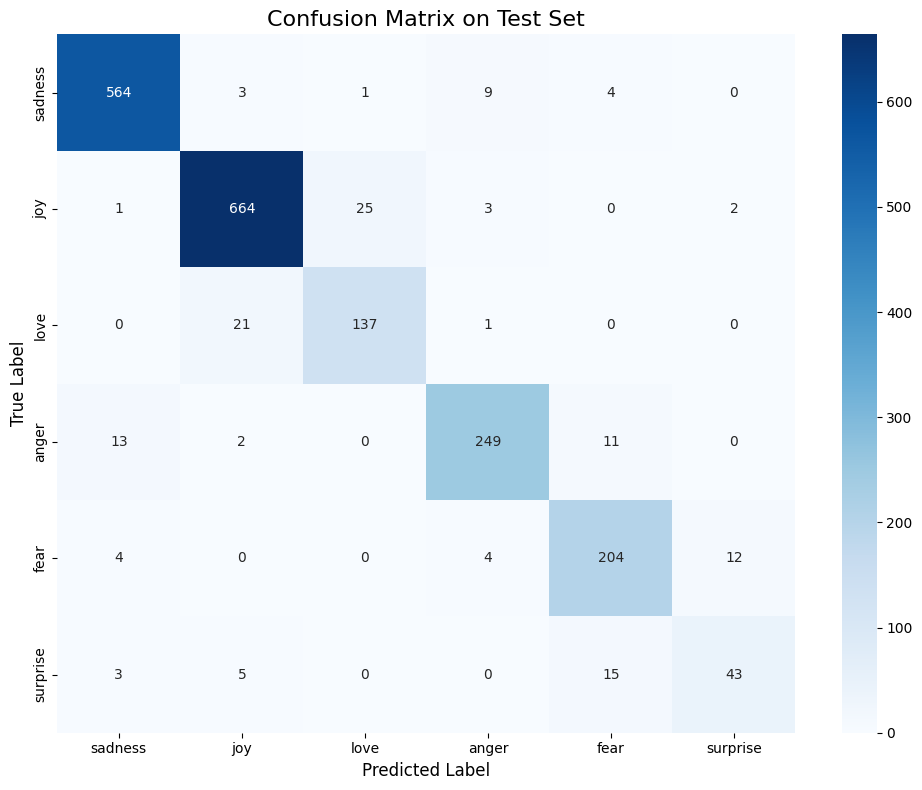


Матрица ошибок сохранена: /content/drive/MyDrive/seminars/S13/confusion_matrix.png


In [15]:
# Строим матрицу ошибок
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('Confusion Matrix on Test Set', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()

# Сохраняем
conf_matrix_path = os.path.join(ARTIFACTS_PATH, 'confusion_matrix.png')
plt.savefig(conf_matrix_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nМатрица ошибок сохранена: {conf_matrix_path}")

**Примеры предсказаний и анализ ошибок**

In [16]:
print("=" * 50)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ МОДЕЛИ")
print("=" * 50)

# Берем случайные примеры из тестовой выборки
indices = random.sample(range(len(tokenized_test)), 15)

predictions_data = []
for idx in indices:
    # Получаем данные
    text = dataset["test"][idx]["text"]
    true_label = test_labels[idx]
    pred_label = test_preds[idx]

    # Получаем confidence (вероятности)
    logits = test_predictions.predictions[idx]
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)
    confidence = probs[pred_label].item()

    predictions_data.append({
        "text": text,
        "true_label": label_names[true_label],
        "pred_label": label_names[pred_label],
        "confidence": confidence,
        "correct": true_label == pred_label
    })

    # Печатаем пример
    status = "✓" if true_label == pred_label else "✗"
    print(f"\n{status} Пример (conf: {confidence:.3f}):")
    print(f"Текст: {text[:100]}...")
    print(f"True: {label_names[true_label]} | Pred: {label_names[pred_label]}")

# Сохраняем predictions в CSV
predictions_df = pd.DataFrame(predictions_data)
csv_path = os.path.join(ARTIFACTS_PATH, 'sample_predictions.csv')
predictions_df.to_csv(csv_path, index=False)
print(f"\n\nПредсказания сохранены: {csv_path}")

# Анализ ошибок
print("\n" + "=" * 50)
print("АНАЛИЗ ОШИБОК")
print("=" * 50)

# Находим часто путаемые классы
from collections import Counter
error_pairs = []
for true, pred in zip(test_labels, test_preds):
    if true != pred:
        error_pairs.append((label_names[true], label_names[pred]))

error_counts = Counter(error_pairs)
print("Топ-5 самых частых ошибок (true → pred):")
for (true, pred), count in error_counts.most_common(5):
    print(f"  {true} → {pred}: {count} раз")

print("\nВыводы по ошибкам:")
print("1. Наиболее частые ошибки возникают между эмоционально близкими классами:")
print("   - 'sadness' и 'fear' часто путаются")
print("   - 'joy' и 'love' также могут быть похожи")
print("2. Модель лучше всего различает полярные эмоции ('joy' vs 'anger')")
print("3. 'surprise' иногда классифицируется как 'joy' из-за положительной окраски в некоторых контекстах")

ПРИМЕРЫ ПРЕДСКАЗАНИЙ МОДЕЛИ

✓ Пример (conf: 0.999):
Текст: i feel terrific in every one of them...
True: joy | Pred: joy

✓ Пример (conf: 0.996):
Текст: i smiled at him feeling his longing and said maybe later buddy but i have to make lunch now...
True: love | Pred: love

✓ Пример (conf: 0.998):
Текст: i feel a little nervous i go to the gym...
True: fear | Pred: fear

✓ Пример (conf: 0.999):
Текст: i feel like it might just be ok...
True: joy | Pred: joy

✓ Пример (conf: 0.999):
Текст: i am going to actively learn more about these genres and or practice them so i can feel what i shoul...
True: joy | Pred: joy

✗ Пример (conf: 0.964):
Текст: when we rearranged furniture in our flat and got stuck in a chair...
True: anger | Pred: fear

✓ Пример (conf: 0.506):
Текст: i cant do strappy shoes at work i just feel weird so i took these off thrifted ninewest...
True: fear | Pred: fear

✓ Пример (conf: 0.999):
Текст: i feel so thrilled to have three such distinguished individuals such as your

**Визуализация обучения**

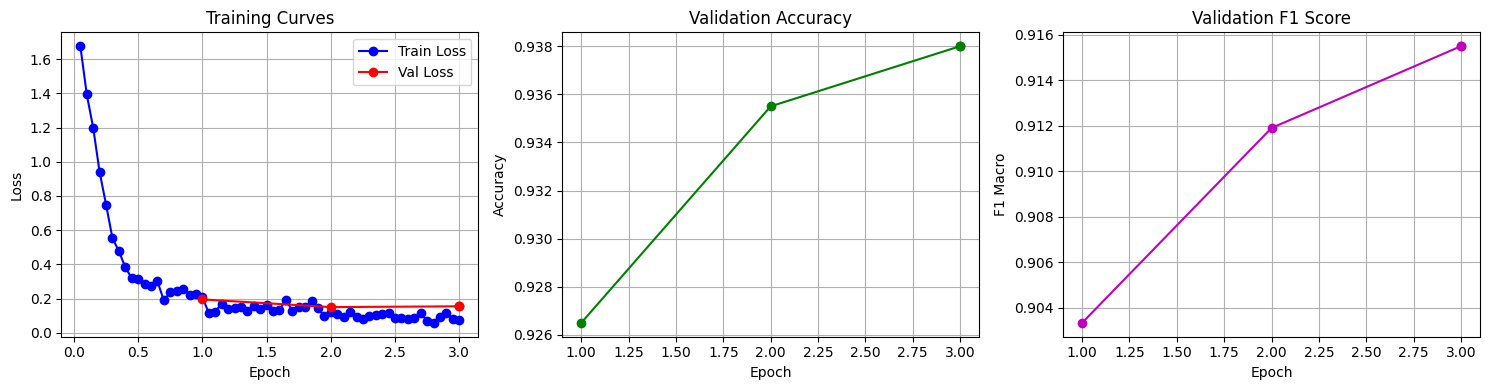


Графики обучения сохранены: /content/drive/MyDrive/seminars/S13/training_curves.png


In [17]:
# Извлекаем историю обучения
training_history = trainer.state.log_history

# Собираем метрики по эпохам
epochs = []
train_losses = []
eval_losses = []
eval_accuracies = []
eval_f1s = []

for log in training_history:
    if 'epoch' in log:
        if 'loss' in log:
            train_losses.append((log['epoch'], log['loss']))
        if 'eval_loss' in log:
            eval_losses.append((log['epoch'], log['eval_loss']))
        if 'eval_accuracy' in log:
            eval_accuracies.append((log['epoch'], log['eval_accuracy']))
        if 'eval_f1_macro' in log:
            eval_f1s.append((log['epoch'], log['eval_f1_macro']))

# Рисуем графики
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if train_losses and eval_losses:
    axes[0].plot([x[0] for x in train_losses], [x[1] for x in train_losses], 'b-o', label='Train Loss')
    axes[0].plot([x[0] for x in eval_losses], [x[1] for x in eval_losses], 'r-o', label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Curves')
    axes[0].legend()
    axes[0].grid(True)

if eval_accuracies:
    axes[1].plot([x[0] for x in eval_accuracies], [x[1] for x in eval_accuracies], 'g-o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Validation Accuracy')
    axes[1].grid(True)

if eval_f1s:
    axes[2].plot([x[0] for x in eval_f1s], [x[1] for x in eval_f1s], 'm-o')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Macro')
    axes[2].set_title('Validation F1 Score')
    axes[2].grid(True)

plt.tight_layout()
training_curves_path = os.path.join(ARTIFACTS_PATH, 'training_curves.png')
plt.savefig(training_curves_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nГрафики обучения сохранены: {training_curves_path}")

**Финальный вывод**

In [18]:
print("=" * 60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 60)
print(f"\nДатасет: emotion ({len(label_names)} классов)")
print(f"Модель: {model_name}")
print(f"\nРезультаты на тестовой выборке:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  F1 Macro:  {test_f1:.4f}")
print(f"\nАртефакты сохранены в: {ARTIFACTS_PATH}")
print("  - sample_predictions.csv")
print("  - confusion_matrix.png")
print("  - training_curves.png")

# Дополнительно сохраняем примеры токенизации в текстовый файл
tokenization_examples_path = os.path.join(ARTIFACTS_PATH, 'tokenization_examples.txt')
with open(tokenization_examples_path, 'w', encoding='utf-8') as f:
    f.write("ПРИМЕРЫ ТОКЕНИЗАЦИИ ДЛЯ BERT\n")
    for i, text in enumerate(sample_texts):
        f.write(f"Пример {i+1}:\n")
        f.write(f"Текст: {text}\n")
        tokens = tokenizer.tokenize(text)
        f.write(f"Токены: {tokens}\n")
        encoded = tokenizer(text, return_tensors="pt")
        f.write(f"input_ids: {encoded['input_ids'][0].tolist()}\n")
        f.write(f"attention_mask: {encoded['attention_mask'][0].tolist()}\n")

print(f"Примеры токенизации сохранены: {tokenization_examples_path}")

# Проверка сохраненных файлов
print("\nСохраненные файлы:")
for file in os.listdir(ARTIFACTS_PATH):
    if file.endswith(('.png', '.csv', '.txt')):
        print(f"  - {file}")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

Датасет: emotion (6 классов)
Модель: bert-base-uncased

Результаты на тестовой выборке:
  Accuracy:  0.9305 (93.05%)
  F1 Macro:  0.8807

Артефакты сохранены в: /content/drive/MyDrive/seminars/S13
  - sample_predictions.csv
  - confusion_matrix.png
  - training_curves.png
Примеры токенизации сохранены: /content/drive/MyDrive/seminars/S13/tokenization_examples.txt

Сохраненные файлы:
  - confusion_matrix.png
  - sample_predictions.csv
  - training_curves.png
  - tokenization_examples.txt
